# Install & Imports

In [1]:
!pip install merlinquantum datasets

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import merlin as ML
from merlin import QuantumLayer, LexGrouping
from merlin.builder import CircuitBuilder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV


# Load Data

In [2]:
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)
df = pd.DataFrame(ds_level1)
df_numeric = df.drop(columns=['Date'])
print("Shape:", df_numeric.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Shape: (494, 224)


# Visualize Data


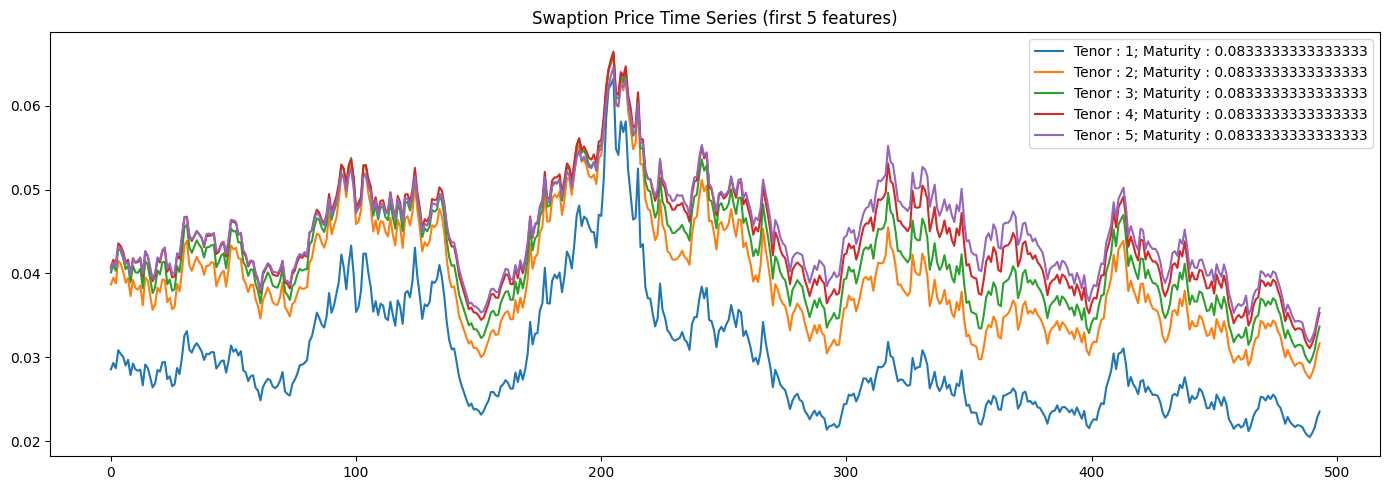

Number of swaption features: 224
Number of time steps (rows): 494


In [3]:
cols_to_plot = df_numeric.columns[:5]
df_numeric[cols_to_plot].plot(figsize=(14, 5), title="Swaption Price Time Series (first 5 features)")
plt.tight_layout()
plt.savefig("timeseries.png")
plt.show()
print("Number of swaption features:", df_numeric.shape[1])
print("Number of time steps (rows):", df_numeric.shape[0])


# Preprocessing


In this cell, we prepare the time series data for supervised learning.
First, we create sliding window sequences so the model uses the previous 3 time steps to predict the next one.
Then, we standardize the data and split it into training (80%) and testing (20%) sets while preserving temporal order.
Finally, we check the shapes and extract input/output dimensions for model configuration.



In [4]:
def make_sequences(data, lookback=3):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

values = df_numeric.values.astype("float32")
scaler = StandardScaler()
values_scaled = scaler.fit_transform(values)

LOOKBACK = 3
X, y = make_sequences(values_scaled, lookback=LOOKBACK)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
n_seq_features = X_train.shape[2]
n_outputs      = y_train.shape[1]

X_train: (392, 3, 224), y_train: (392, 224)



# Quantum Circuit

In this cell, we define the quantum feature extractor architecture.
We build a small photonic circuit (with encoding, entangling layers, and rotations) and wrap it as a QuantumLayer, followed by a feature grouping layer.
Then, we create an ensemble of 3 quantum circuits with different random seeds to enrich feature diversity.
Finally, we compute the total number of extracted features per sample.



In [5]:
N_MODES      = 6
N_PHOTONS    = 3
N_QUANTUM_IN = 4
GROUPING_DIM = 16

# Same random projection as working version
torch.manual_seed(42)
proj_matrix = torch.randn(n_seq_features, N_QUANTUM_IN) * 0.1

def build_extractor():
    builder = CircuitBuilder(n_modes=N_MODES)
    builder.add_entangling_layer(trainable=True, name="U1")
    builder.add_angle_encoding(modes=list(range(N_QUANTUM_IN)), name="input")
    builder.add_rotations(trainable=True, name="theta")
    builder.add_superpositions(depth=1)
    core = QuantumLayer(
        input_size=N_QUANTUM_IN,
        builder=builder,
        n_photons=N_PHOTONS,
        dtype=torch.float32,
    )
    grouping = LexGrouping(core.output_size, GROUPING_DIM)
    extractor = nn.Sequential(core, grouping)
    extractor.eval()
    return extractor

# TWEAK 1: Build 3 circuits with different seeds, concatenate features
# This is the QR2 ensemble idea but conservative — same small circuit
extractors = []
for seed in [42, 7, 123]:
    torch.manual_seed(seed)
    extractors.append(build_extractor())

print(f"Built {len(extractors)} quantum circuits")
print(f"Total features per sample: {LOOKBACK * GROUPING_DIM * len(extractors)}")

Built 3 quantum circuits
Total features per sample: 144


# Feature extraction

In this cell, we extract quantum features from the time-series data.
Each timestep is first projected to a low-dimensional quantum input space, then passed through multiple quantum circuits to generate features.
Features from all circuits and timesteps are concatenated into a single vector per sample.
Finally, we compute and store the quantum features for both training and test sets.

In [13]:
def extract_quantum_features(X_np):
    """
    X_np: (B, T, F)
    Returns: (B, T * GROUPING_DIM * n_circuits)
    """
    B, T, F = X_np.shape
    X_t = torch.tensor(X_np, dtype=torch.float32)

    all_features = []
    for t in range(T):
        xt     = X_t[:, t, :]           # (B, F)
        xt_proj = torch.sigmoid(xt @ proj_matrix)  # (B, N_QUANTUM_IN) in [0,1]

        timestep_feats = []
        for ext in extractors:
            with torch.no_grad():
                qf = ext(xt_proj)       # (B, GROUPING_DIM)
            timestep_feats.append(qf)

        all_features.append(torch.cat(timestep_feats, dim=1))  # (B, GROUPING_DIM*3)

    return torch.cat(all_features, dim=1).numpy()  # (B, T * GROUPING_DIM * 3)

print("Extracting training features...")
Q_train = extract_quantum_features(X_train)
print("Extracting test features...")
Q_test  = extract_quantum_features(X_test)
print(f"Feature shape: {Q_train.shape}")

Extracting training features...
Extracting test features...
Feature shape: (392, 144)


# Tweek
In this cell, we train a Ridge regression model on the extracted quantum features.
We use cross-validation to automatically select the best regularization strength (alpha).
After training, we generate predictions for both the training and test sets.

In [7]:
alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(Q_train, y_train)
print(f"Best alpha: {ridge.alpha_}")

y_pred_test  = ridge.predict(Q_test)
y_pred_train = ridge.predict(Q_train)

Best alpha: 0.5


# MLP and LSTM Baselines
In this cell, we prepare PyTorch tensors for both flattened and sequential inputs.
We define a generic training loop using Adam and a learning rate scheduler.
Then, we implement two classical baseline models: an MLP (using flattened inputs) and an LSTM (using sequential inputs).
Finally, we train both models to compare their performance against the quantum-based approach.

In [8]:
X_tr_flat = torch.tensor(X_train.reshape(len(X_train), -1), dtype=torch.float32)
X_te_flat = torch.tensor(X_test.reshape(len(X_test),   -1), dtype=torch.float32)
X_tr_seq  = torch.tensor(X_train, dtype=torch.float32)
X_te_seq  = torch.tensor(X_test,  dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32)
n_flat_features = X_tr_flat.shape[1]

def train_model(model, X_tr, y_tr, epochs=200, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=80, gamma=0.5)
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        loss = F.mse_loss(model(X_tr), y_tr)
        loss.backward()
        opt.step()
        scheduler.step()
        if ep % 50 == 0:
            print(f"  Epoch {ep:3d}: loss={loss.item():.6f}")

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_flat_features, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_outputs)
        )
    def forward(self, x): return self.net(x)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(n_seq_features, hidden_size=64, num_layers=2, batch_first=True)
        self.head = nn.Linear(64, n_outputs)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

print("Training MLP..."); mlp = MLP(); train_model(mlp, X_tr_flat, y_tr)
print("Training LSTM..."); lstm_model = LSTMModel(); train_model(lstm_model, X_tr_seq, y_tr)

Training MLP...
  Epoch   0: loss=1.080894
  Epoch  50: loss=0.072903
  Epoch 100: loss=0.039444
  Epoch 150: loss=0.036887
Training LSTM...
  Epoch   0: loss=1.085615
  Epoch  50: loss=0.225068
  Epoch 100: loss=0.073400
  Epoch 150: loss=0.048154


# Metrics:
In this cell, we define evaluation metrics to assess model performance.
Predictions are first transformed back to the original scale before computing RMSE, MAE, and QLIKE.
We create separate evaluation functions for NumPy-based (Ridge) and PyTorch models.
Finally, we compare the Quantum Ridge model with the MLP and LSTM baselines on the test set.

In [9]:
def compute_metrics_np(preds_scaled, true_scaled):
    preds_orig = scaler.inverse_transform(preds_scaled)
    true_orig  = scaler.inverse_transform(true_scaled)
    rmse  = np.sqrt(np.mean((preds_orig - true_orig)**2))
    mae   = np.mean(np.abs(preds_orig - true_orig))
    eps   = 1e-8
    qlike = np.mean(np.log(true_orig**2 + eps) + preds_orig / (true_orig + eps))
    return {"RMSE": round(rmse,6), "MAE": round(mae,6), "QLIKE": round(qlike,6)}

def compute_metrics_torch(model, X_te, y_te):
    model.eval()
    with torch.no_grad():
        preds = model(X_te).numpy()
    return compute_metrics_np(preds, y_te.numpy())

print("\n===== RESULTS =====")
print("QRC (3-circuit ensemble + RidgeCV):", compute_metrics_np(y_pred_test, y_test))
print("MLP Baseline:                      ", compute_metrics_torch(mlp,        X_te_flat, y_te))
print("LSTM Baseline:                     ", compute_metrics_torch(lstm_model, X_te_seq,  y_te))




===== RESULTS =====
QRC (3-circuit ensemble + RidgeCV): {'RMSE': np.float32(0.006933), 'MAE': np.float32(0.004951), 'QLIKE': np.float32(-2.395055)}
MLP Baseline:                       {'RMSE': np.float32(0.004281), 'MAE': np.float32(0.003195), 'QLIKE': np.float32(-2.401103)}
LSTM Baseline:                      {'RMSE': np.float32(0.00727), 'MAE': np.float32(0.005481), 'QLIKE': np.float32(-2.396529)}


# Plot
In this cell, we visualize and compare the predictions of all models.
We first convert predictions back to the original scale.
Then, we plot actual vs predicted values for the Quantum model, MLP, and LSTM in separate subplots.
Finally, we save the figure to compare model performance visually.

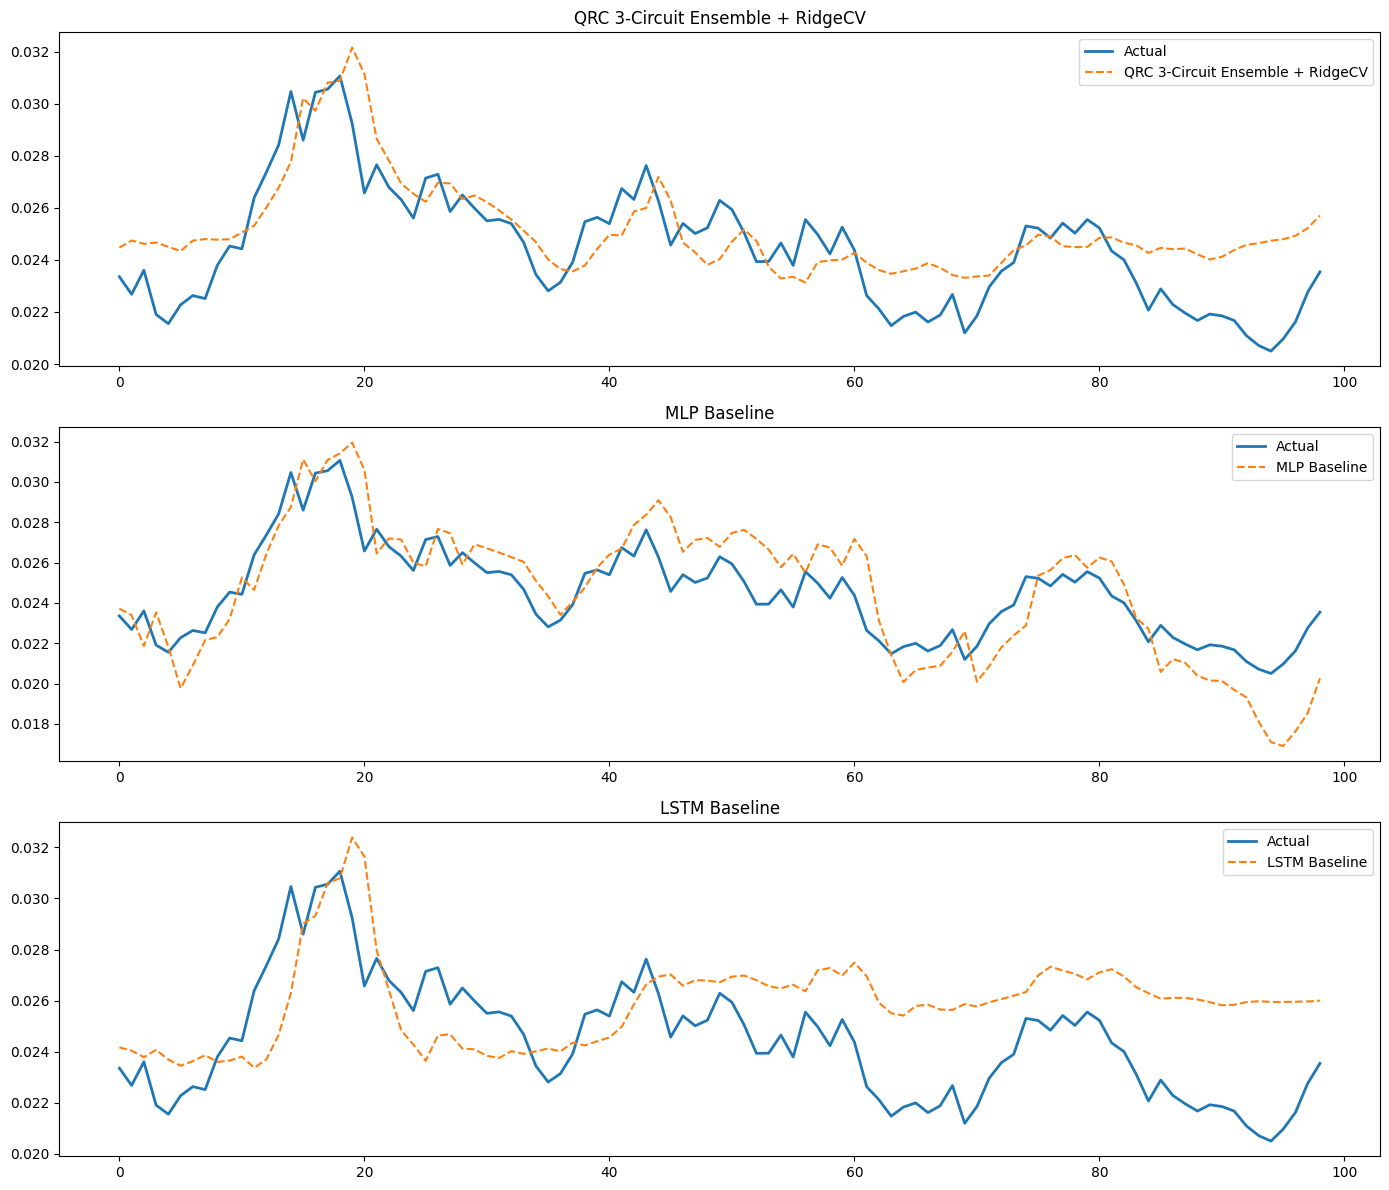

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
true_orig = scaler.inverse_transform(y_test)

mlp.eval(); lstm_model.eval()
with torch.no_grad():
    mlp_preds  = mlp(X_te_flat).numpy()
    lstm_preds = lstm_model(X_te_seq).numpy()

for ax, (preds_scaled, name) in zip(axes, [
    (y_pred_test, "QRC 3-Circuit Ensemble + RidgeCV"),
    (mlp_preds,   "MLP Baseline"),
    (lstm_preds,  "LSTM Baseline"),
]):
    pred_orig = scaler.inverse_transform(preds_scaled)
    ax.plot(true_orig[:, 0], label="Actual", linewidth=2)
    ax.plot(pred_orig[:, 0], label=name,     linestyle="--")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig("all_predictions.png")
plt.show()


# Prediction
In this cell, we prepare the unseen test data for final prediction.
We scale it using the same scaler and add the last training timesteps to preserve temporal context.
Then, we generate sequences, extract quantum features, and produce predictions using the trained Ridge model.
Finally, we convert predictions back to the original scale and save them as submission.csv.

In [12]:
df_test = pd.read_excel("/content/test.xlsx")
if 'Date' in df_test.columns:
    df_test = df_test.drop(columns=['Date'])

test_vals   = df_test.values.astype("float32")
test_scaled = scaler.transform(test_vals)

last_train_rows          = values_scaled[-LOOKBACK:]
test_scaled_with_context = np.concatenate([last_train_rows, test_scaled], axis=0)

X_final, _ = make_sequences(test_scaled_with_context, lookback=LOOKBACK)
print(f"X_final shape: {X_final.shape}")  # (6, 3, F)

Q_final      = extract_quantum_features(X_final)
final_preds  = ridge.predict(Q_final)

final_preds_orig = scaler.inverse_transform(final_preds)
submission = pd.DataFrame(final_preds_orig, columns=df_numeric.columns)
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv!")
print(submission.round(6))

X_final shape: (6, 3, 224)
Saved submission.csv!
   Tenor : 1; Maturity : 0.0833333333333333  \
0                                  0.026049   
1                                  0.026195   
2                                  0.026564   
3                                  0.026911   
4                                  0.027440   
5                                  0.028393   

   Tenor : 2; Maturity : 0.0833333333333333  \
0                                  0.034108   
1                                  0.034398   
2                                  0.035011   
3                                  0.035581   
4                                  0.036398   
5                                  0.037562   

   Tenor : 3; Maturity : 0.0833333333333333  \
0                                  0.036250   
1                                  0.036531   
2                                  0.037138   
3                                  0.037693   
4                                  0.038483   
5        